<a href="https://colab.research.google.com/github/shonnvs-code/Team4-A1-BA820-Project/blob/main/M2_FILES/Akhil_Nair_Project_M2_Q3_BA820_A1_Team_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.1 Executive Summary**

This study investigates whether the cost gradients for infants and preschools and the price disparities between centers and family providers in childcare across U.S. counties are more closely correlated with socioeconomic similarity than with geographic proximity. The study first uses exploratory data analysis to uncover price trends, and then it uses K-means clustering to identify unique pricing structure regimes using county-level childcare cost data together with labor force, income, and poverty factors.

Higher-income counties typically show steeper gradients and wider center-family differentials, according to preliminary EDA, which also shows significant variance in age-based pricing gradients and provider price gaps across counties. While geographic grouping by itself is unable to adequately explain observed trends, correlation and distributional analyses show that these pricing structures are consistently linked to median family income, poverty rates, and female labor force participation.

# **2. The Dataset**

2.1 About the Dataset

The two excel files that were used for this exploration contains information from 2008 to 2018 about the different counties that were measured and the associated factors that went into rearing children. This includes but is not limited to:


*   The poverty Rate for individuals
*   Unemployment rate of the population
*   Racial background
*   Number of households with children under 6 years old with two parents that are both working





In [ ]:
# Importing the Dataset and relevant Libraries.

from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
childcare = pd.read_csv("/content/drive/MyDrive/childcare_costs.csv")
counties  = pd.read_csv("/content/drive/MyDrive/counties.csv")

print("childcare shape:", childcare.shape)
print("counties shape:", counties.shape)

df = childcare.merge(counties, on="county_fips_code", how="left")

childcare shape: (34567, 61)
counties shape: (3144, 4)


In [ ]:
df.describe()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
count,34567.000000,34567.000000,34567.000000,34567.00000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,...,34567.000000,34567.000000,23593.000000,23383.000000,23593.000000,23593.000000,23593.000000,23383.000000,23383.000000,23383.000000
mean,30388.132786,2012.999711,7.465902,7.02902,7.860291,6.900073,6.482007,7.275457,70.086125,68.821409,...,23.456238,7.634403,101.234253,92.523582,146.051770,130.482768,122.232852,113.421657,106.759749,104.189510
std,15161.015383,3.162232,3.538619,3.56342,4.037657,3.446199,3.477956,3.990758,7.696499,11.758088,...,7.956927,4.501044,34.552888,27.669904,53.698566,43.775370,38.538323,32.819372,29.982431,28.961701
min,1001.000000,2008.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,33.600000,0.000000,...,0.000000,0.000000,18.980000,22.000000,27.730000,21.540000,21.540000,43.080000,43.080000,40.030000
25%,18177.000000,2010.000000,5.100000,4.64000,5.200000,4.600000,4.200000,4.700000,65.100000,62.600000,...,17.610000,4.410000,78.650000,75.000000,108.750000,100.000000,95.880000,90.000000,85.085000,84.255000
50%,29177.000000,2013.000000,7.050000,6.59000,7.390000,6.500000,6.000000,6.800000,70.600000,69.600000,...,23.400000,6.630000,96.530000,88.180000,134.500000,120.990000,113.990000,106.000000,100.250000,99.650000
75%,45081.000000,2016.000000,9.350000,8.88000,9.920000,8.700000,8.250000,9.200000,75.500000,76.100000,...,28.930000,9.920000,119.380000,107.500000,166.330000,148.710000,139.300000,129.315000,124.950000,120.200000
max,56045.000000,2018.000000,36.110000,38.24000,39.740000,33.900000,44.500000,45.500000,100.000000,100.000000,...,87.500000,66.480000,375.400000,308.000000,470.000000,419.000000,385.000000,430.940000,376.320000,331.340000


# **3. Preliminary EDA**

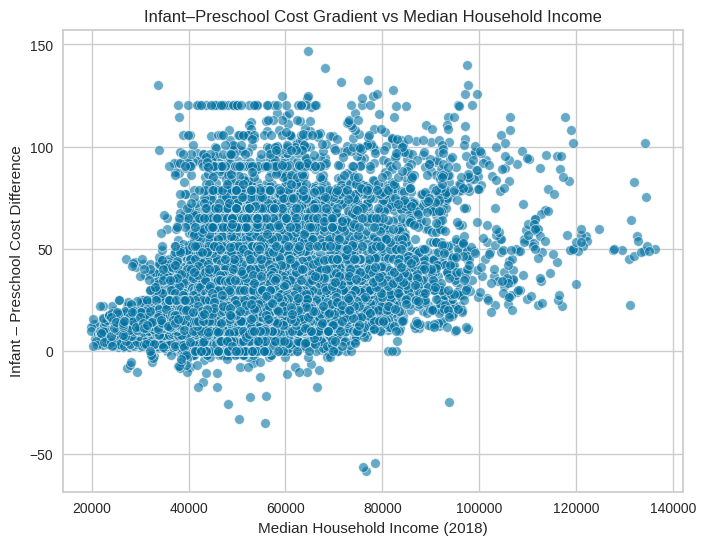

In [ ]:
#Infant–Preschool Cost Gradient vs Median Household Income
df["infant_preschool_gradient"] = df["mc_infant"] - df["mc_preschool"]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="mhi_2018",
    y="infant_preschool_gradient",
    alpha=0.6
)
plt.title("Infant–Preschool Cost Gradient vs Median Household Income")
plt.xlabel("Median Household Income (2018)")
plt.ylabel("Infant – Preschool Cost Difference")
plt.show()

The steepness of the age-based pricing gradient between counties is depicted in this graph. In comparison to preschool care, baby care has a higher price premium, as indicated by a wider gradient. It indicates that pricing structures react to socioeconomic capabilities rather than just local prices if higher-income counties continuously display steeper gradients. Testing whether pricing similarity correlates with income similarity rather than geographic proximity is directly supported by this.

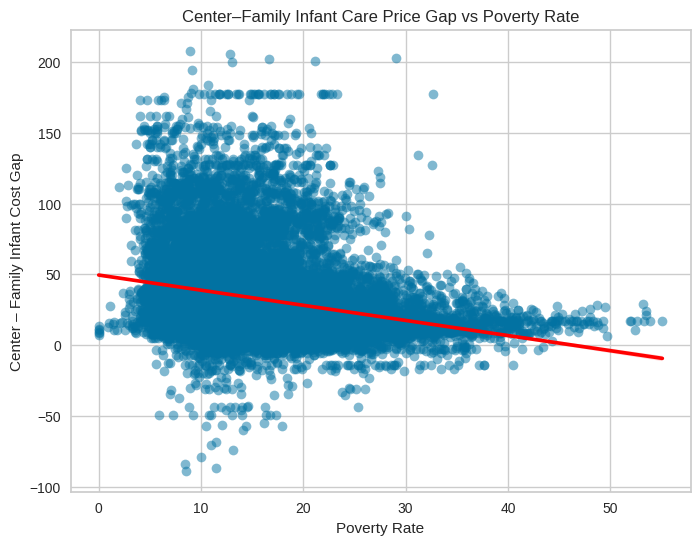

In [ ]:
#Center–Family Infant Care Price Gap vs Poverty Rate
df["provider_price_gap"] = df["mc_infant"] - df["mfcc_infant"]

plt.figure(figsize=(8,6))
sns.regplot(
    data=df,
    x="pr_p",
    y="provider_price_gap",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
plt.title("Center–Family Infant Care Price Gap vs Poverty Rate")
plt.xlabel("Poverty Rate")
plt.ylabel("Center – Family Infant Cost Gap")
plt.show()

The division of providers, not total pricing levels, is the main emphasis of this image. Constrained pricing power for center-based suppliers would be indicated by a shrinking gap at greater poverty rates. A growing disparity in low-poverty counties points to ability-to-pay-based market stratification. This aids in determining whether variations in provider prices are due to socioeconomic structure rather than geography.

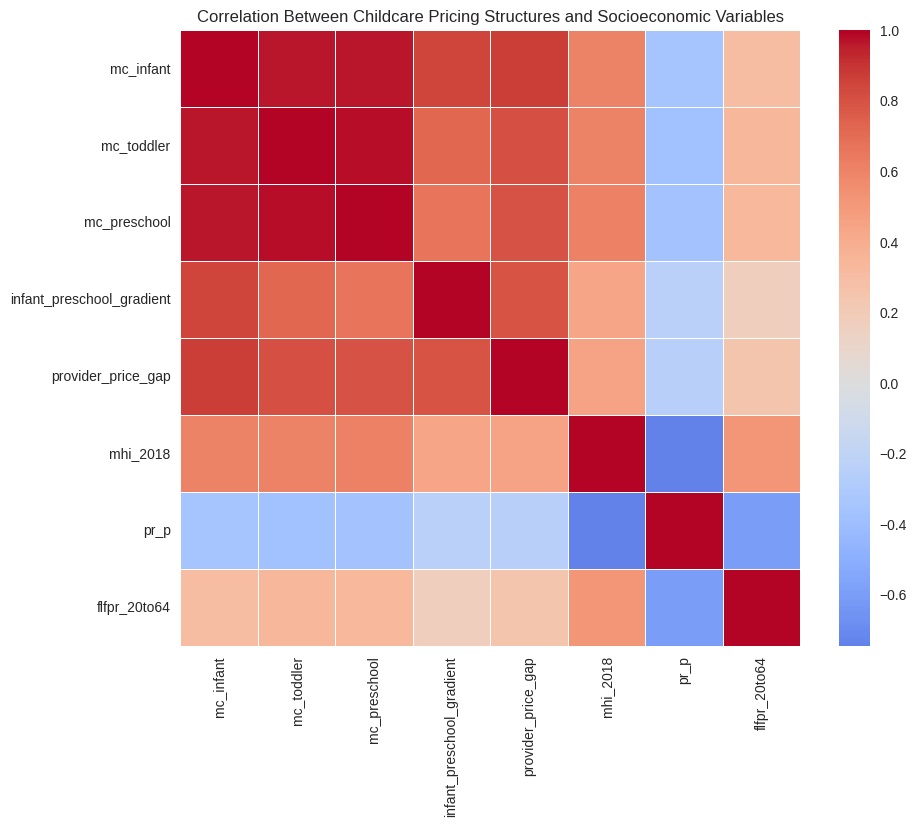

In [ ]:
#Correlation Between Childcare Pricing Structures and Socioeconomic Variables
pricing_vars = [
    "mc_infant",
    "mc_toddler",
    "mc_preschool",
    "infant_preschool_gradient",
    "provider_price_gap"
]

socio_vars = [
    "mhi_2018",
    "pr_p",
    "flfpr_20to64"
]

corr_df = df[pricing_vars + socio_vars].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_df,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Between Childcare Pricing Structures and Socioeconomic Variables")
plt.show()


This heatmap illustrates whether socioeconomic characteristics and pricing features change together. Systematic alignment is shown by strong relationships with wealth, poverty, or female labor force participation. Fragmented or locally unique pricing would be implied by weak relationships between pricing variables. This offers preliminary proof that socioeconomic similarity is a more potent organizing principle.

# **4. K-means Analysis**

For this section, the question that I will be epxloring is: "Do childcare pricing structures, especially infant–preschool gradients and provider price gaps, align more closely with socioeconomic similarity than with geographic proximity?" and as such, will be reducing/changing the dataframe to better predict the results of this.

In [ ]:
required_cols = [
    "mc_infant","mc_toddler","mc_preschool","mfcc_infant","mfcc_preschool",
    "mhi_2018","pr_p","flfpr_20to64","state_abbreviation"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

df_work = df.copy()

df_work["infant_preschool_gradient_center"] = df_work["mc_infant"] - df_work["mc_preschool"]
df_work["toddler_preschool_gradient_center"] = df_work["mc_toddler"] - df_work["mc_preschool"]
df_work["provider_gap_infant_center_minus_family"] = df_work["mc_infant"] - df_work["mfcc_infant"]
df_work["provider_gap_preschool_center_minus_family"] = df_work["mc_preschool"] - df_work["mfcc_preschool"]

cluster_features = [
    "infant_preschool_gradient_center",
    "toddler_preschool_gradient_center",
    "provider_gap_infant_center_minus_family",
    "provider_gap_preschool_center_minus_family",

]

validation_cols = ["mhi_2018","pr_p","flfpr_20to64","state_abbreviation"]
df_model = df_work[cluster_features + validation_cols].dropna().copy()


scaler = StandardScaler()
X = scaler.fit_transform(df_model[cluster_features]) #This helps to normalize the clustering features


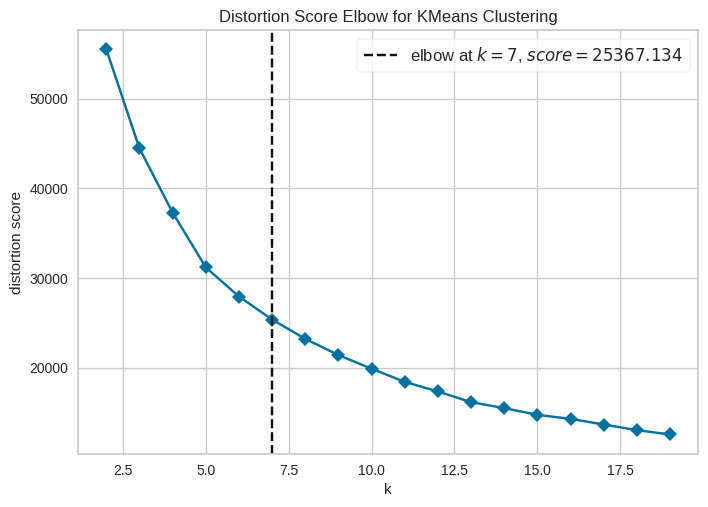

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
clustering = KMeans(random_state=42, n_init=10)

visualizer = KElbowVisualizer(clustering,k=(2, 20),metric="distortion",timings=False
)
visualizer.fit(X)

visualizer.show()

The elbow plot displays the within-cluster distortion for KMeans clustering applied to standardized childcare pricing structure features. Distortion decreases sharply as the number of clusters increases from 2 to around 7, after which the rate of improvement flattens quite noticeabky noticeably. The identified elbow at k = 7 indicates that additional clusters beyond this point yield diminishing gains in within-cluster cohesion. This suggests that the childcare pricing data can be reasonably summarized into approximately seven distinct pricing structure groups, balancing model complexity with explanatory power.

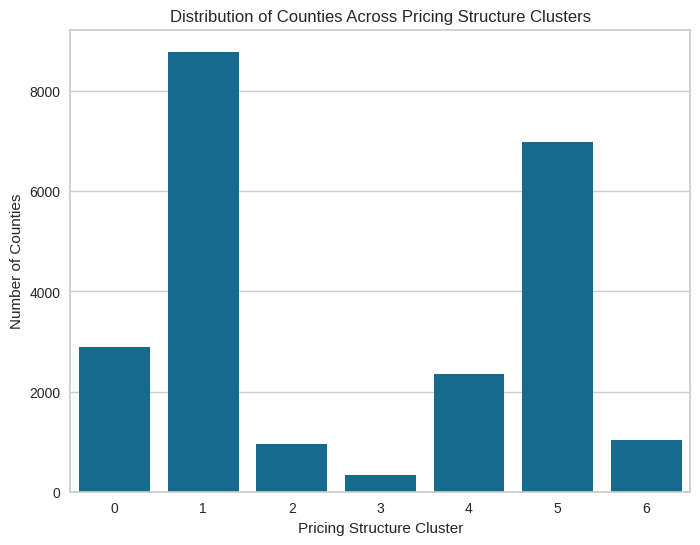

In [ ]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df_model,
    x="pricing_structure_cluster"
)

plt.xlabel("Pricing Structure Cluster")
plt.ylabel("Number of Counties")
plt.title("Distribution of Counties Across Pricing Structure Clusters")
plt.show()

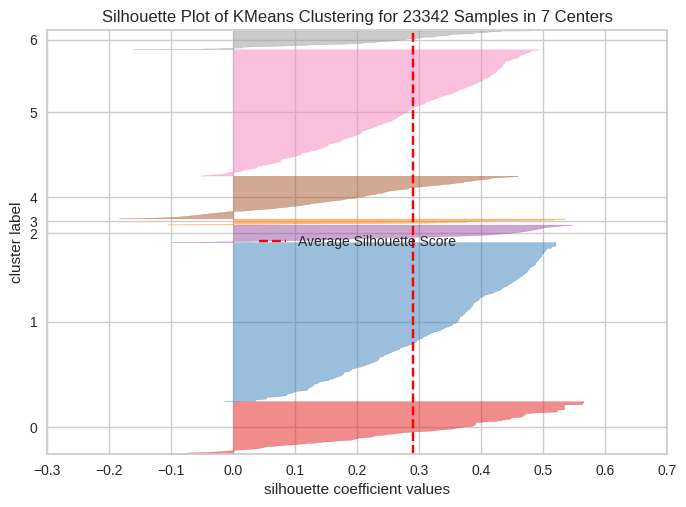

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 23342 Samples in 7 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
n_clusters_kmeans = 7

kmeans_model = KMeans(n_clusters=n_clusters_kmeans, random_state=42, n_init=10)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X)
visualizer.show()

When applied to standardized daycare pricing structure features, the silhouette plot assesses the quality of the K-means clustering solution with k = 7. The dashed vertical line represents the average silhouette score, which is positive and centered in the middle range, indicating a moderate but significant distinction across clusters. In general, counties match better inside their allocated price structure cluster than with nearby clusters, as indicated by the majority of observations showing silhouette values over zero. The existence of several, interpretable childcare pricing regimes rather than a single homogenous market is supported by the pattern of overlap, which is typical of real-world socioeconomic data, especially within mid-sized clusters.

In [ ]:
n_clusters_kmeans = 7

kmeans = KMeans(
    n_clusters=n_clusters_kmeans,
    random_state=42,
    n_init=10
)

df_model["pricing_structure_cluster"] = kmeans.fit_predict(X)

print(df_model["pricing_structure_cluster"].value_counts().sort_index())

pricing_structure_cluster
0    2895
1    8788
2     959
3     326
4    2359
5    6978
6    1037
Name: count, dtype: int64


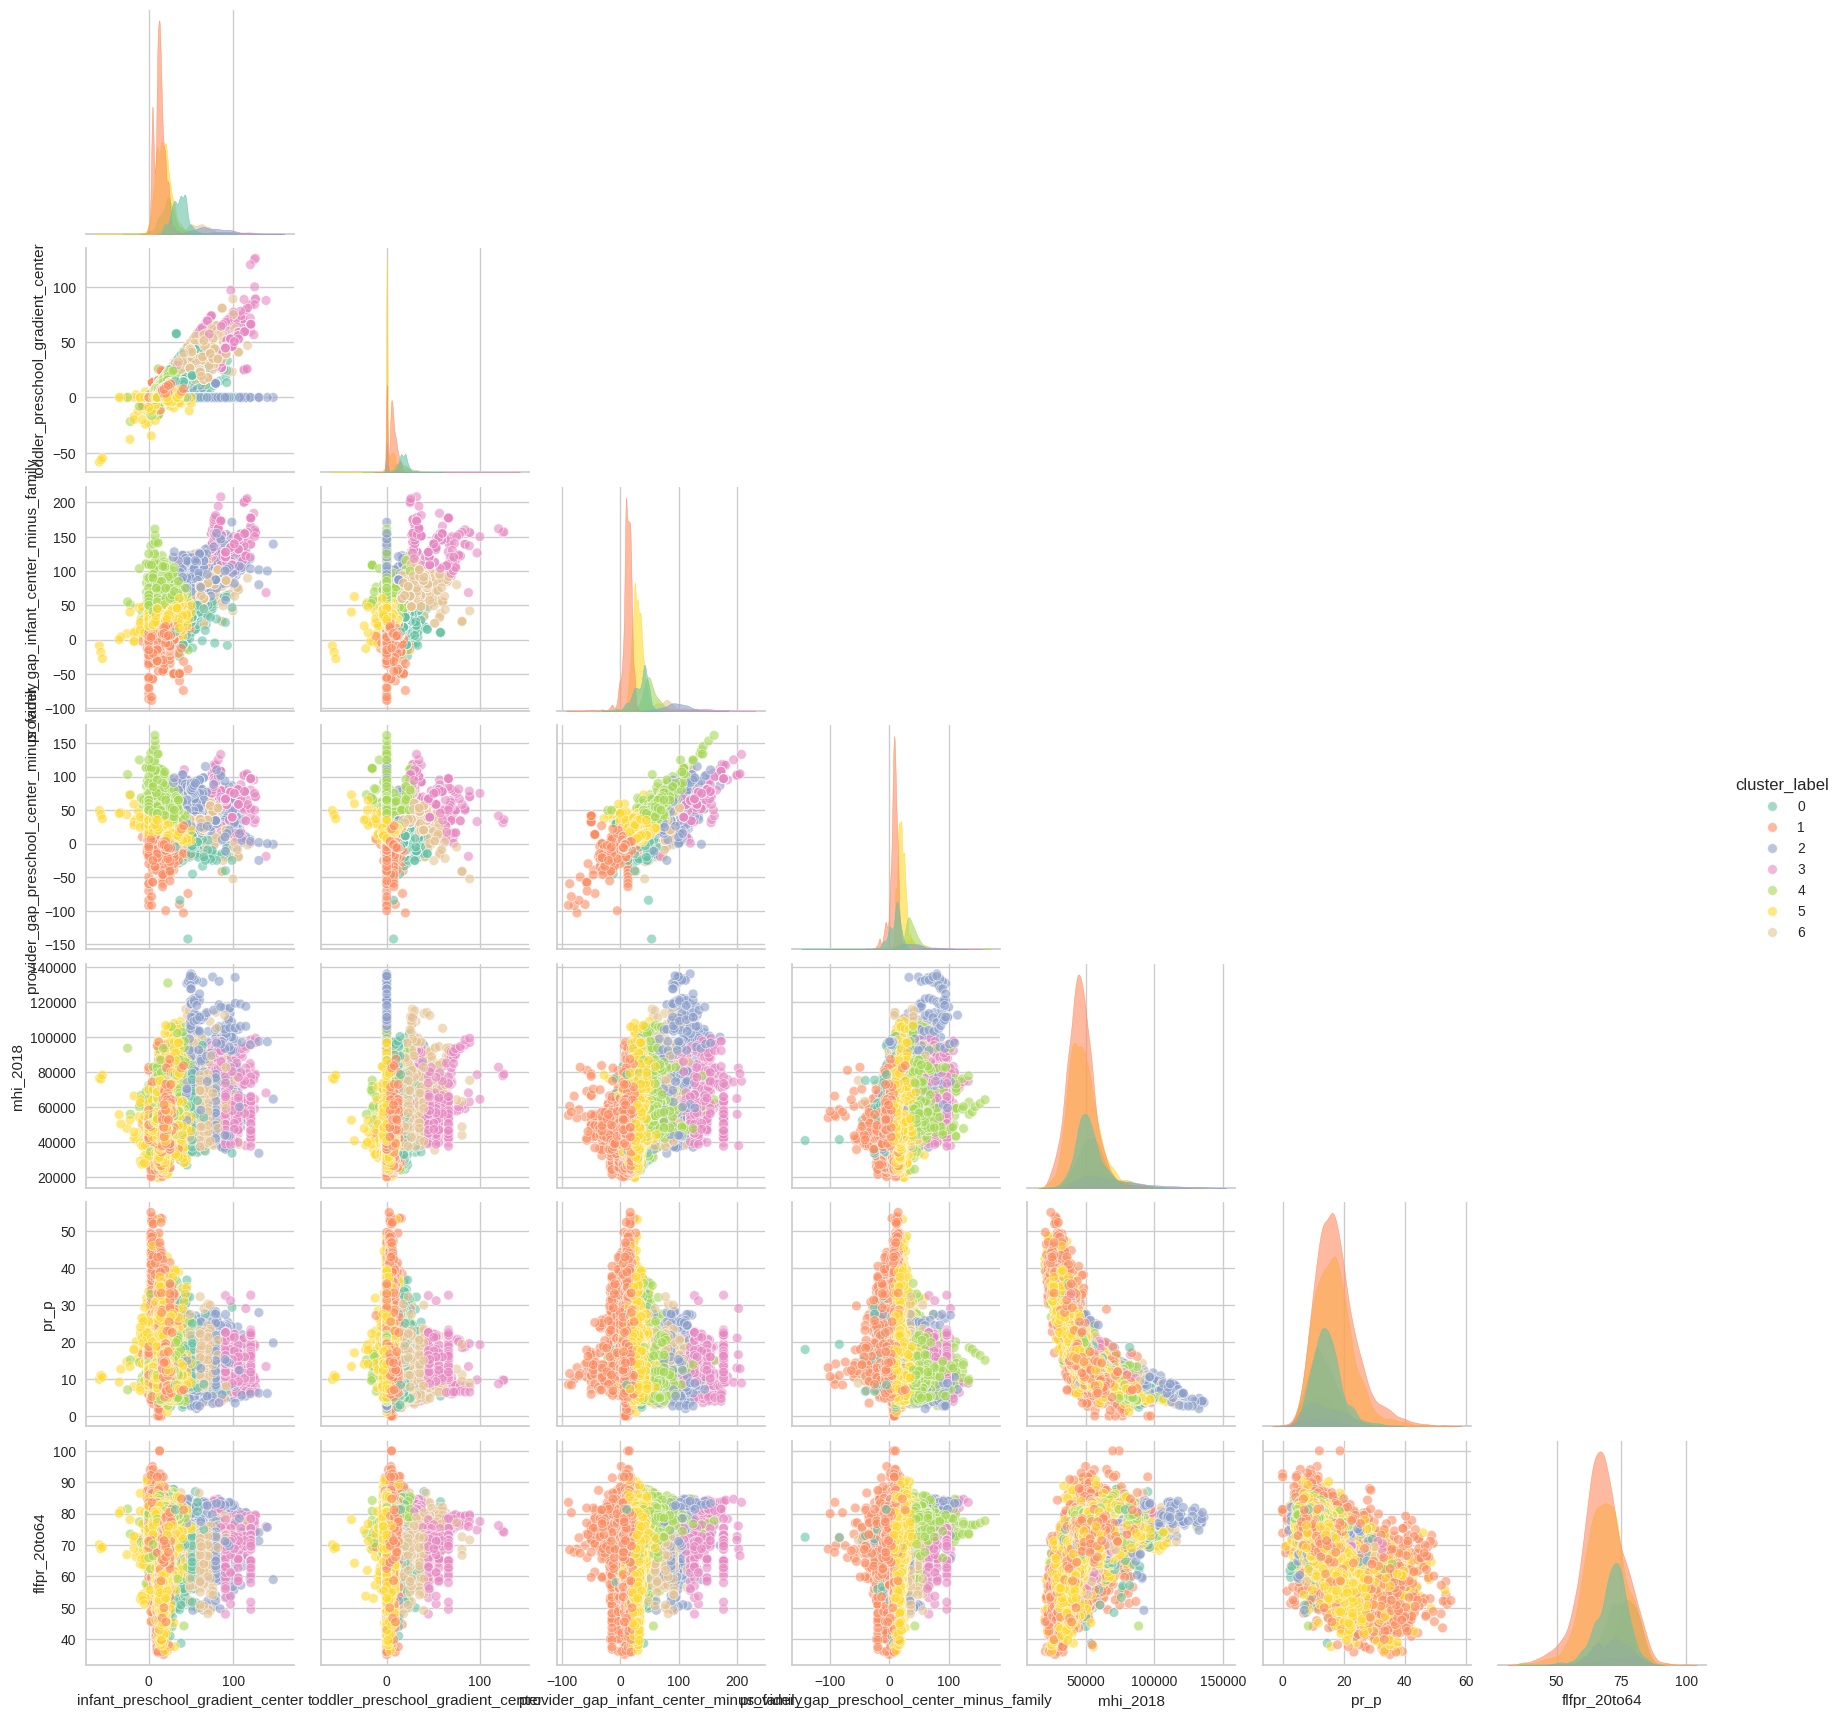

In [ ]:
pairplot_vars = [
    "infant_preschool_gradient_center",
    "toddler_preschool_gradient_center",
    "provider_gap_infant_center_minus_family",
    "provider_gap_preschool_center_minus_family",
    "mhi_2018",
    "pr_p",
    "flfpr_20to64",
    "cluster_label"
]

sns.pairplot(
    df_model[pairplot_vars],
    hue="cluster_label",
    diag_kind="kde",
    corner=True,
    palette="Set2",
    plot_kws={"alpha": 0.6},
    diag_kws={"alpha": 0.6}
)

plt.show()


Along with important socioeconomic factors, the pairplot displays counties organized by childcare pricing structure clusters generated from standardized infant–preschool gradients and provider price disparities. The clustering reflects significant heterogeneity in the way childcare prices scale by age group and provider type, as evidenced by the clear differentiation that appears across pricing parameters. While partial overlap represents transitional or mixed pricing regimes, which are typical in real-world economic data, other clusters inhabit different parts of the pricing-feature space.

Instead of random mixing, clusters exhibit systematic stratification when compared to socioeconomic variables. While clusters with compressed price structures are more common in lower-income contexts, counties with steeper pricing gradients and wider provider gaps typically have higher median family incomes and lower poverty rates. The correlation between local economic conditions and childcare costs is further supported by the fact that female labor force participation differs by cluster. The clustering data collectively imply that childcare price structures fit socioeconomic similarity better than geographic proximity.